<h1 style='text-align:center;color:green;font-weight:bold'>  Fashion Retail Customer & Sales Analysis </h1>
<h3 style='text-align:center'>Understanding Sales Trends, Customer Segments, and Product Performance</h3>

<p>The goal is to analyze customer purchase behavior, segment customers based on their spending patterns,<br> 
and evaluate the performance of products over time. By doing so, we aim to gain actionable insights into customer <br> segments and their preferences, as well as identify trends in sales and product performance.

Additionally, the project will help determine which customers are driving the most revenue and assess how various<br>  factors (such as payment methods, review ratings, and the time of purchase) influence buying behavior.</p>

### Importing Essential Python Libraries

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading And Overview

In [197]:
df = pd.read_csv('Fashion_Retail_Sales.csv')

In [198]:
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash


In [199]:
df.shape

(3400, 6)

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


In [201]:
df.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


### Cleaning Data And Preprocessing

In [202]:
df.isnull().sum()

Customer Reference ID      0
Item Purchased             0
Purchase Amount (USD)    650
Date Purchase              0
Review Rating            324
Payment Method             0
dtype: int64

In [203]:
# Handling Missing Values By Replace With Mean Value
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(value=df['Purchase Amount (USD)'].mean())
df['Review Rating'] = df['Review Rating'].fillna(value=df['Review Rating'].mean())

In [204]:
### Change Date Purchase in Datetime Data Type
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'],format="%d-%m-%Y")

In [205]:
df.dtypes

Customer Reference ID             int64
Item Purchased                   object
Purchase Amount (USD)           float64
Date Purchase            datetime64[ns]
Review Rating                   float64
Payment Method                   object
dtype: object

### Feature Engineering

In [206]:
df['Year'] = df['Date Purchase'].dt.year
df['Month'] = df['Date Purchase'].dt.month
df['Weak Day'] = df['Date Purchase'].dt.day_name()

In [207]:
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method,Year,Month,Weak Day
0,4018,Handbag,4619.0,2023-02-05,2.999057,Credit Card,2023,2,Sunday
1,4115,Tunic,2456.0,2023-07-11,2.000000,Credit Card,2023,7,Tuesday
2,4019,Tank Top,2102.0,2023-03-23,4.100000,Cash,2023,3,Thursday
3,4097,Leggings,3126.0,2023-03-15,3.200000,Cash,2023,3,Wednesday
4,3997,Wallet,3003.0,2022-11-27,4.700000,Cash,2022,11,Sunday


### Purchase Amount (USD) And Review Rating Distribution

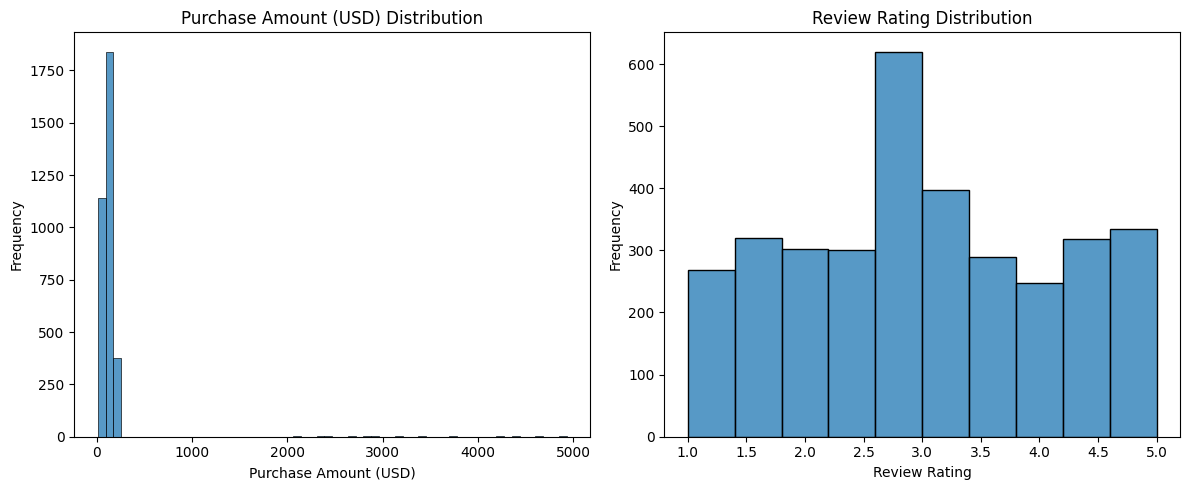

In [208]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x='Purchase Amount (USD)',bins=60,ax=ax[0])
ax[0].set_ylabel('Frequency')
ax[0].set_title('Purchase Amount (USD) Distribution')


sns.histplot(data=df,x='Review Rating',bins=10,ax=ax[1])
ax[1].set_ylabel('Frequency')
ax[1].set_title('Review Rating Distribution')

# Show both plots together
plt.tight_layout()
plt.show()

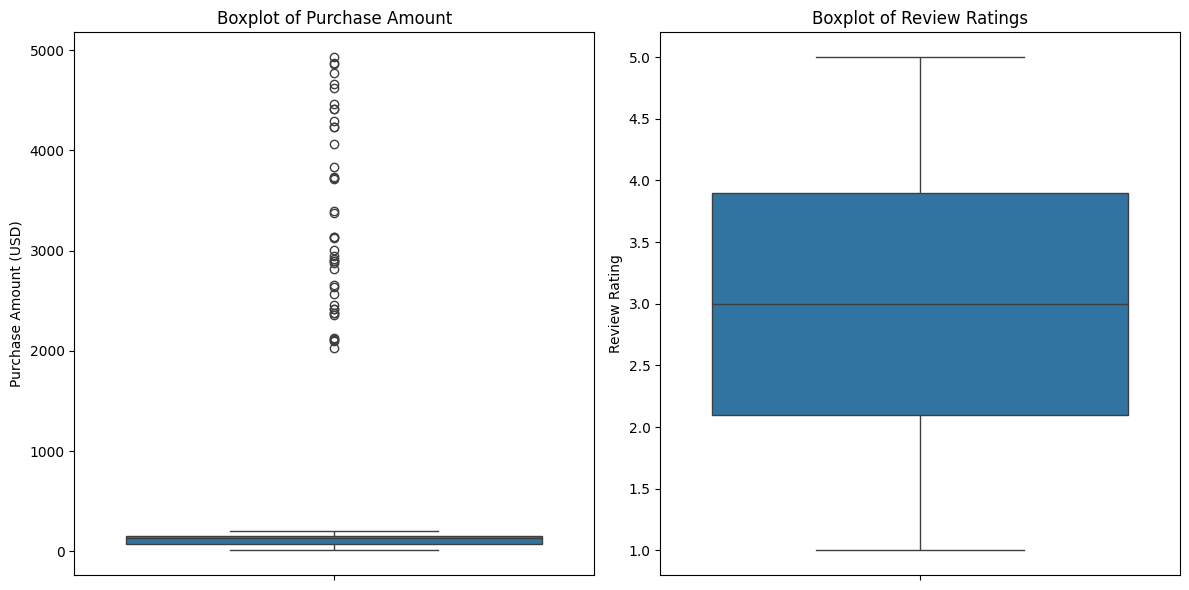

In [209]:
# Create a 1x2 subplot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot for Purchase Amount
sns.boxplot(data=df, y='Purchase Amount (USD)', ax=ax[0])
ax[0].set_title('Boxplot of Purchase Amount')

# Boxplot for Review Rating
sns.boxplot(data=df, y='Review Rating', ax=ax[1])
ax[1].set_title('Boxplot of Review Ratings')

# Show both plots together
plt.tight_layout()
plt.show()


###  Annual Sales Trend Analysis

In [210]:
annual_sales = df.groupby('Year')['Purchase Amount (USD)'].agg(lambda x: round(x.sum(),2)).reset_index()
annual_sales

,Year,Purchase Amount (USD)
0,2022,138022.28
1,2023,394791.10


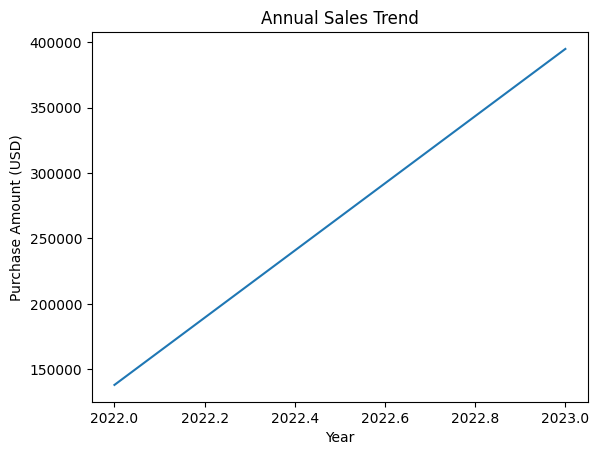

In [211]:
sns.lineplot(data=annual_sales,x='Year',y='Purchase Amount (USD)')
plt.title('Annual Sales Trend')
plt.show()

In [212]:
monthly_sales = df.groupby('Month')['Purchase Amount (USD)'].agg(lambda x: round(x.sum(),2)).reset_index()
monthly_sales

,Month,Purchase Amount (USD)
0,1,38506.04
1,2,42184.62
2,3,46431.94
3,4,49622.59
4,5,54441.17
5,6,43847.62
6,7,42108.46
7,8,44114.62
8,9,33111.04
9,10,41107.72


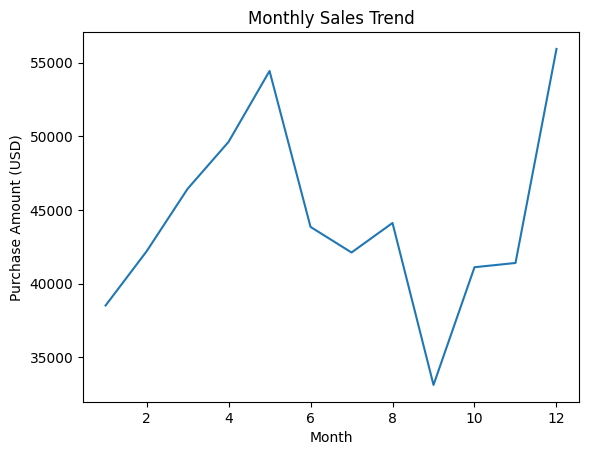

In [213]:
sns.lineplot(data=monthly_sales,x='Month',y='Purchase Amount (USD)')
plt.title('Monthly Sales Trend')
plt.show()

In [214]:
weakly_sales = df.groupby('Weak Day')['Purchase Amount (USD)'].agg(lambda x: round(x.sum(),2)).reset_index()
weakly_sales

,Weak Day,Purchase Amount (USD)
0,Friday,83295.79
1,Monday,79079.30
2,Saturday,66278.88
3,Sunday,88578.37
4,Thursday,72541.85
5,Tuesday,76766.14
6,Wednesday,66273.04


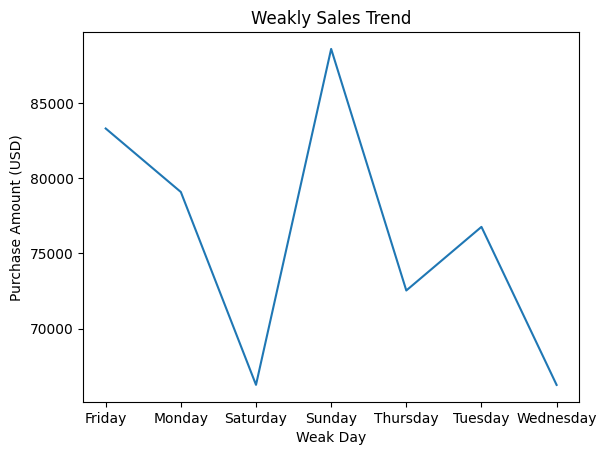

In [215]:
sns.lineplot(data=weakly_sales,x='Weak Day',y='Purchase Amount (USD)')
plt.title('Weakly Sales Trend')
plt.show()

### Cumulative Year-to-Date (YTD) Sales, Orders, and Quantity Analysis
-- Purpose: Track the year-to-date progression of sales, orders, and quantity by year

In [216]:
# 3. Group by Year and calculate yearly totals
yearly_data = df.groupby('Year').agg({
    'Purchase Amount (USD)': 'sum',
    'Customer Reference ID': 'count',
    'Item Purchased': 'count'
}).reset_index().rename(columns={
    'Purchase Amount (USD)': 'Total Sales',
    'Customer Reference ID': 'Total Orders',
    'Item Purchased': 'Total Quantity'
})

# 4. Calculate Cumulative (YTD) totals
yearly_data['YTD Sales'] = yearly_data['Total Sales'].cumsum()
yearly_data['YTD Orders'] = yearly_data['Total Orders'].cumsum()
yearly_data['YTD Quantity'] = yearly_data['Total Quantity'].cumsum()
yearly_data

,Year,Total Sales,Total Orders,Total Quantity,YTD Sales,YTD Orders,YTD Quantity
0,2022,138022.280727,853,853,138022.280727,853,853
1,2023,394791.101091,2547,2547,532813.381818,3400,3400


#### 1. bar Plots for Sales, Orders, Quantity

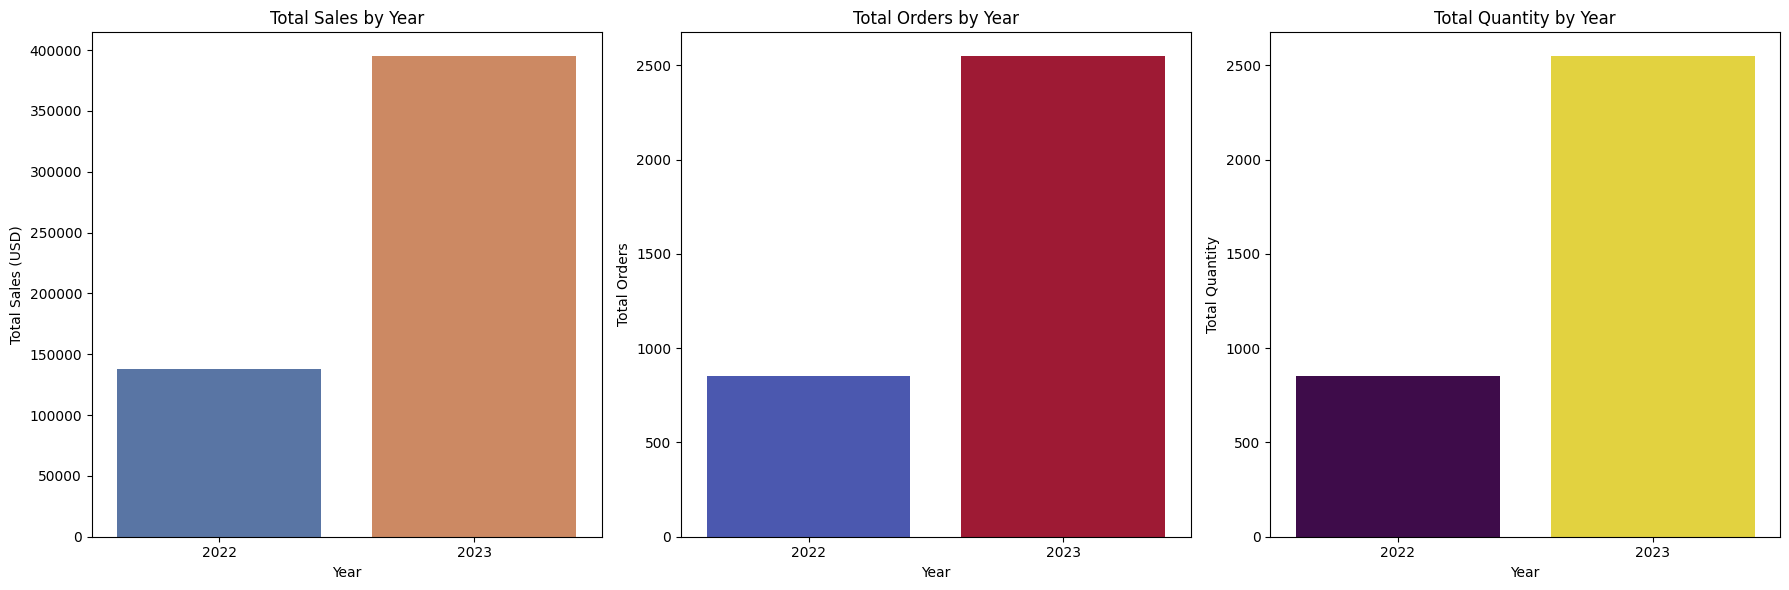

In [217]:
# Plot Yearly Totals (Sales, Orders, Quantity)
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Total Sales (Using hue argument to assign color palette)
sns.barplot(data=yearly_data, x='Year', y='Total Sales', ax=ax[0], hue='Year', palette='deep', legend=False)
ax[0].set_title('Total Sales by Year')
ax[0].set_ylabel('Total Sales (USD)')
ax[0].set_xlabel('Year')

# Total Orders
sns.barplot(data=yearly_data, x='Year', y='Total Orders', ax=ax[1], hue='Year', palette='coolwarm', legend=False)
ax[1].set_title('Total Orders by Year')
ax[1].set_ylabel('Total Orders')
ax[1].set_xlabel('Year')

# Total Quantity
sns.barplot(data=yearly_data, x='Year', y='Total Quantity', ax=ax[2], hue='Year', palette='viridis', legend=False)
ax[2].set_title('Total Quantity by Year')
ax[2].set_ylabel('Total Quantity')
ax[2].set_xlabel('Year')

plt.tight_layout()
plt.show()


#### 2. Line Plot for Cumulative Totals (YTD Sales, YTD Orders, YTD Quantity)

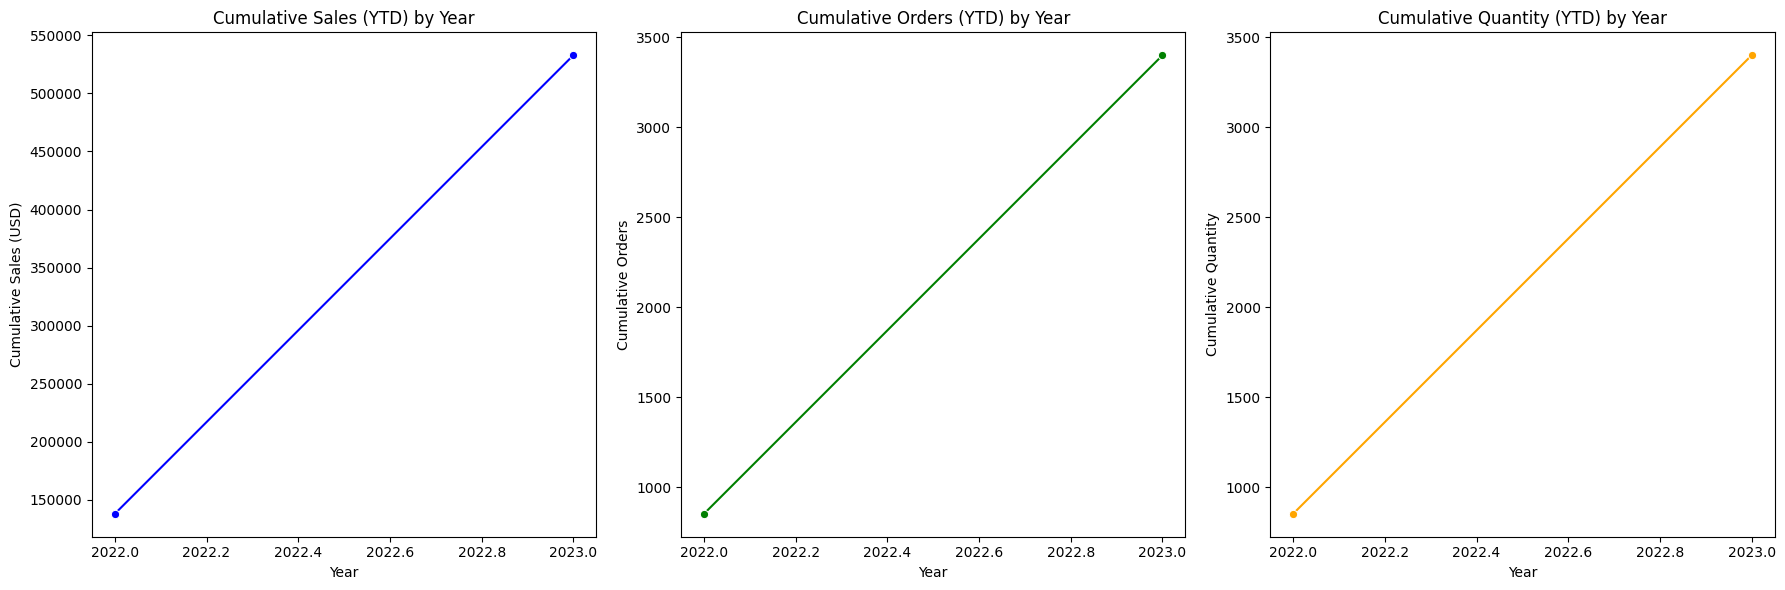

In [218]:
# Plot YTD Cumulative Values
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# YTD Sales
sns.lineplot(data=yearly_data, x='Year', y='YTD Sales', ax=ax[0], marker='o', color='blue')
ax[0].set_title('Cumulative Sales (YTD) by Year')
ax[0].set_ylabel('Cumulative Sales (USD)')
ax[0].set_xlabel('Year')

# YTD Orders
sns.lineplot(data=yearly_data, x='Year', y='YTD Orders', ax=ax[1], marker='o', color='green')
ax[1].set_title('Cumulative Orders (YTD) by Year')
ax[1].set_ylabel('Cumulative Orders')
ax[1].set_xlabel('Year')

# YTD Quantity
sns.lineplot(data=yearly_data, x='Year', y='YTD Quantity', ax=ax[2], marker='o', color='orange')
ax[2].set_title('Cumulative Quantity (YTD) by Year')
ax[2].set_ylabel('Cumulative Quantity')
ax[2].set_xlabel('Year')

plt.tight_layout()
plt.show()


### Year-over-Year (YoY) Sales Change Analysis
-- Purpose: Evaluate annual sales performance by calculating year-over-year change and trend direction

In [219]:
yearly_sales = df.groupby('Year')['Purchase Amount (USD)'].agg(lambda x: round(x.sum(),2)).reset_index()

# 4. Calculate YoY change and trend direction
yearly_sales['Previous Sales'] = yearly_sales['Purchase Amount (USD)'].shift(1)

# 5. Calculate % change
yearly_sales['YoY Change (%)'] = round(
    ((yearly_sales['Purchase Amount (USD)'] - yearly_sales['Previous Sales']) / yearly_sales['Previous Sales']) * 100, 2
)

# 6. Determine trend direction
yearly_sales['Trend'] = yearly_sales.apply(
    lambda row: 'Increase' if row['Purchase Amount (USD)'] > row['Previous Sales']
    else ('Decrease' if row['Purchase Amount (USD)'] < row['Previous Sales'] else 'No Change'),
    axis=1
)
yearly_sales

,Year,Purchase Amount (USD),Previous Sales,YoY Change (%),Trend
0,2022,138022.28,NaN,NaN,No Change
1,2023,394791.10,138022.28,186.03,Increase


### Payment Method Vs Purchase Amount (USD)

In [220]:
payment_method_sales =  df.groupby('Payment Method')['Purchase Amount (USD)'].sum().reset_index()
payment_method_sales

,Payment Method,Purchase Amount (USD)
0,Cash,250171.722182
1,Credit Card,282641.659636


[]

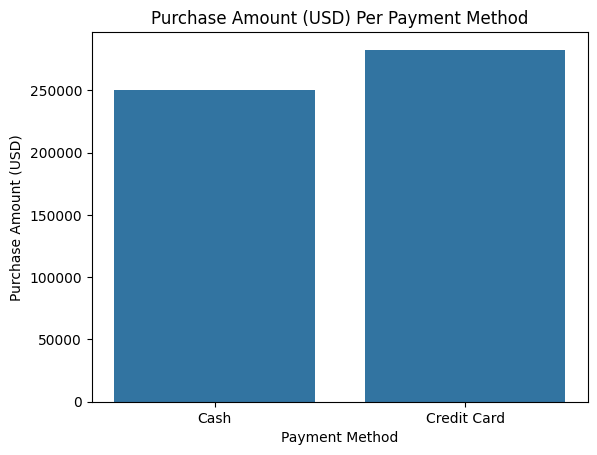

In [221]:
sns.barplot(data=payment_method_sales,x='Payment Method',y='Purchase Amount (USD)')
plt.title('Purchase Amount (USD) Per Payment Method')
plt.plot()

In [222]:
df.columns

Index(['Customer Reference ID', 'Item Purchased', 'Purchase Amount (USD)',
       'Date Purchase', 'Review Rating', 'Payment Method', 'Year', 'Month',
       'Weak Day'],
      dtype='object')

### Purchase Amount (USD) With Review Rating

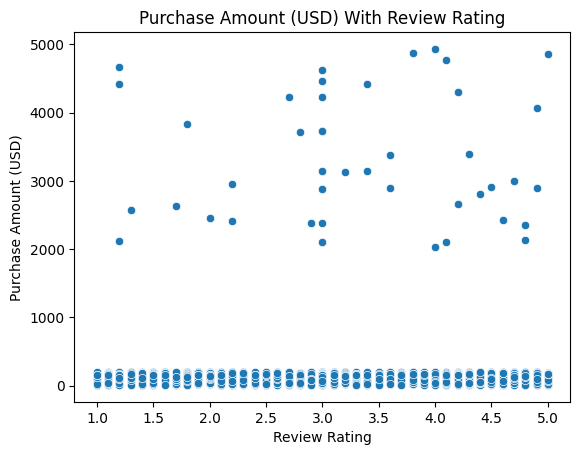

In [223]:
sns.scatterplot(data = df[['Review Rating','Purchase Amount (USD)']],x='Review Rating',y='Purchase Amount (USD)')
plt.title('Purchase Amount (USD) With Review Rating')
plt.show()

### Top Ten Selling Products

In [224]:
item_purchased_sales = df.groupby('Item Purchased')['Purchase Amount (USD)'].agg(lambda x: round(x.sum(),2)).head(10).reset_index()
item_purchased_sales.sort_values(by='Purchase Amount (USD)', ascending=False, ignore_index=True)

,Item Purchased,Purchase Amount (USD)
0,Boots,13928.23
1,Belt,13774.91
2,Blouse,12979.36
3,Blazer,12649.07
4,Cardigan,10993.81
5,Bowtie,9958.68
6,Backpack,8675.36
7,Camisole,8329.94
8,Coat,7904.65
9,Dress,6144.23


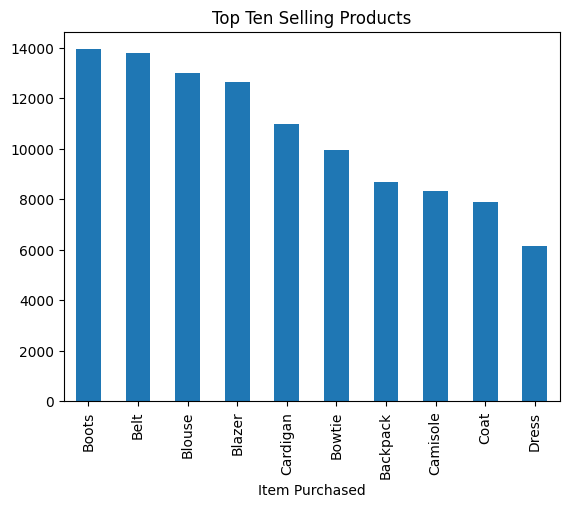

In [225]:
item_purchased_sales.sort_values(
    by='Purchase Amount (USD)', ascending=False, ignore_index=True
).plot(kind='bar',x='Item Purchased',y='Purchase Amount (USD)',legend=False)
plt.title('Top Ten Selling Products')
plt.show()

### Customer Purchase Patterns and Segmentation

In [226]:
customer_status = df.groupby('Customer Reference ID').agg(
    Total_Purchase = ('Purchase Amount (USD)','sum'),
    First_Purchase=('Date Purchase', 'min'),
    Last_Purchase=('Date Purchase', 'max')
).reset_index().sort_values(by='First_Purchase')

# getting months customer stay
from dateutil.relativedelta import relativedelta

# Define a function to calculate month difference
def month_diff(start, end):
    rd = relativedelta(end, start)
    return rd.years * 12 + rd.months

# Apply the function
customer_status['Months_Active'] = customer_status.apply(
    lambda row: month_diff(row['First_Purchase'], row['Last_Purchase']),
    axis=1
)
# categorise castomers acourding money spent and months active stayed
def cust_categ(row):
    x = row['Total_Purchase']
    y= row['Months_Active']
    if x >= 3000 and y >= 9:
        return 'Vip'
    elif x < 3000 and y >= 9:
        return 'Ordiary'
    else:
        return 'New'

customer_status['Customer_Category'] = customer_status.apply(cust_categ,axis=1)
customer_status.head().sort_values(by='Total_Purchase',ascending=False,ignore_index=True)

,Customer Reference ID,Total_Purchase,First_Purchase,Last_Purchase,Months_Active,Customer_Category
0,4008,3034.258909,2022-10-02,2023-09-07,11,Vip
1,4071,2486.129455,2022-10-02,2023-08-23,10,Ordiary
2,4025,2156.839273,2022-10-02,2023-09-25,11,Ordiary
3,4020,2114.129455,2022-10-02,2023-09-26,11,Ordiary
4,4014,1315.419636,2022-10-02,2023-09-22,11,Ordiary


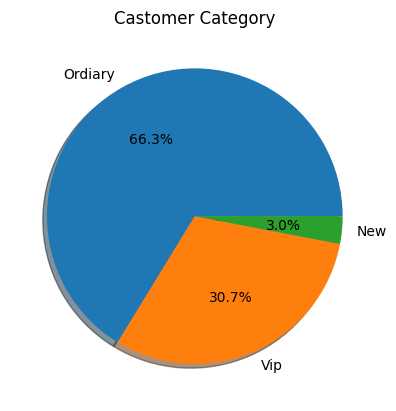

In [227]:
customer_status['Customer_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',       # Optional: shows percentage
    #startangle=90,           # Optional: rotates pie chart for better layout
    shadow=True,             # Optional: adds shadow
    legend=False             # Optional: hide legend
)
plt.ylabel('')
plt.title('Castomer Category')
plt.show()

### Product Performance Analysis and Segmentation

In [232]:
product_segment = df.groupby('Item Purchased').agg(
    Purchase_Amount_USD=('Purchase Amount (USD)', 'sum'),
    Average_Review_Rating=('Review Rating', 'mean')
).reset_index()



#find average product value
average_product_value = product_segment['Purchase_Amount_USD'].mean()

#finding purchase value difference

product_segment['Purchase_Value_Difference'] = product_segment['Purchase_Amount_USD'] - average_product_value 
product_segment['Product_Segment'] = product_segment['Purchase_Value_Difference'].apply(
    lambda x: 'Above Average' if x > 0 else('Below Average' if x < 0 else 'Average')
)
product_segment.head()

,Item Purchased,Purchase_Amount_USD,Average_Review_Rating,Purchase_Value_Difference,Product_Segment
0,Backpack,8675.357091,3.059089,-1980.910545,Below Average
1,Belt,13774.906182,3.001048,3118.638545,Above Average
2,Blazer,12649.066909,3.044991,1992.799273,Above Average
3,Blouse,12979.357091,2.930008,2323.089455,Above Average
4,Boots,13928.227636,3.199898,3271.960000,Above Average


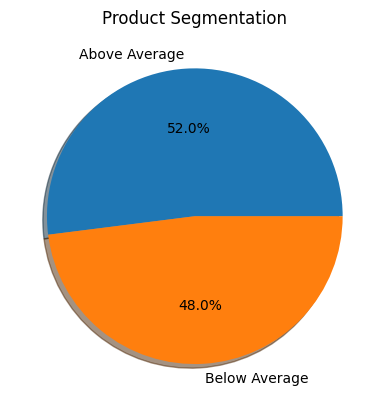

In [234]:
product_segment['Product_Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',       # Optional: shows percentage
    #startangle=90,           # Optional: rotates pie chart for better layout
    shadow=True,             # Optional: adds shadow
    legend=False             # Optional: hide legend
)
plt.ylabel('')
plt.title('Product Segmentation')
plt.show()

### Correlation Analysis 

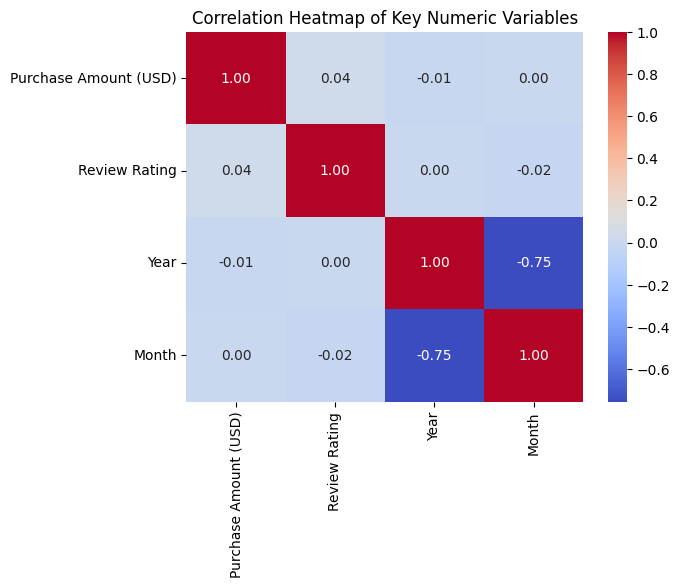

In [229]:
# Select only numeric columns
data = df[['Purchase Amount (USD)', 'Review Rating', 'Year', 'Month']]

# Compute correlation matrix
corr = data.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Numeric Variables')
plt.show()